# 04 - Hyperparameter Optimization

## Optimización de hiperparámetros para clasificación y regresión del riesgo operacional

En este notebook se optimizan los modelos finales del proyecto.

Después del modelado supervisado, los mejores enfoques fueron:

- **Clasificación:** `riesgo_operacional_alto`
- **Regresión:** `riesgo_operacional`

El objetivo de este notebook es comparar el rendimiento de:

- modelo base;
- `GridSearchCV`;
- `Optuna`.

La pregunta principal es:

> ¿Cuál es la mejor configuración final de hiperparámetros para los modelos de clasificación y regresión?


# Objetivos del notebook

En este notebook voy a:

- cargar el dataset final `dataset_modelo_v3.csv`;
- reconstruir los targets finales;
- preparar el preprocesamiento;
- optimizar `RandomForestClassifier`;
- optimizar `RandomForestRegressor`;
- comparar modelo base, GridSearchCV y Optuna;
- analizar el impacto real de la optimización;
- seleccionar las configuraciones finales del proyecto.

Este notebook se enfoca en optimización, no en volver a probar todos los modelos.  
La comparación general de modelos ya se realizó en el notebook `03_supervised_modeling.ipynb`.


# 1. Concepto de hiperparámetros

Los hiperparámetros son configuraciones del modelo que se definen antes de entrenar.

En Random Forest, algunos hiperparámetros importantes son:

- `n_estimators`: cantidad de árboles;
- `max_depth`: profundidad máxima de los árboles;
- `min_samples_split`: mínimo de muestras para dividir un nodo;
- `min_samples_leaf`: mínimo de muestras en una hoja.

Optimizar estos valores puede mejorar el rendimiento, controlar el sobreajuste y hacer el modelo más estable.


# 2. Estrategias utilizadas

## GridSearchCV

Prueba combinaciones específicas definidas manualmente.

Es una técnica clásica, clara y fácil de documentar.

## Optuna

Realiza una búsqueda más flexible e inteligente.

En vez de probar una grilla fija, explora el espacio de hiperparámetros y busca mejores combinaciones de forma automática.

En este notebook se utilizan ambos enfoques para comparar sus resultados.


# 3. Importación de librerías

In [29]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)


# 4. Carga del dataset V3

In [2]:
df = pd.read_csv("data/05_model_input/dataset_modelo_v3.csv")

print("Dimensiones:", df.shape)

df.head()


Dimensiones: (998, 56)


,id_envio,fecha_envio,id_ruta,id_vehiculo,peso_kg,volumen_m3,tipo_carga,estado,fecha_entrega,origen,destino,distancia_km,tiempo_estimado_hrs,tipo_via,peaje_total,placa,tipo,capacidad_kg,capacidad_m3,año_fabricacion,estado_vehiculo,km_recorridos,cantidad_incidencias,costo_total_incidencias,tipo_incidencia_principal,tiene_incidencia,dias_entrega,velocidad_promedio_km_h,uso_capacidad_kg,uso_capacidad_m3,entrega_tardia,peso_kg_original,distancia_km_original,velocidad_promedio_km_h_original,uso_capacidad_kg_original,uso_capacidad_m3_original,uso_capacidad_kg_recalculado,uso_capacidad_m3_recalculado,antiguedad_vehiculo,densidad_carga,riesgo_operacional,riesgo_velocidad,vehiculo_exigido,sobrecarga_kg,ruta_larga,velocidad_alta,vehiculo_riesgoso_estado,via_compleja,peso_kg_log,distancia_km_log,volumen_m3_log,velocidad_promedio_km_h_log,densidad_carga_log,riesgo_operacional_log,riesgo_velocidad_log,km_recorridos_log
0,1.0,2023-01-01,39.0,46.0,12675.8,28.48,peligrosa,entregado,2023-01-05,valparaíso,chillán,919.3,16.7,urbana,1950.0,ouuc-52,camión,10000.0,20.5,2022.0,en mantención,17043.0,0.0,0.0,sin incidencia,0.0,4.0,55.047904,1.26758,1.389268,1,12675.8,919.3,55.047904,1.26758,1.389268,1.26758,1.389268,4.0,445.061620,1165.286294,50605.538323,1,1,0,0,1,0,9.447529,6.824700,3.383712,4.026207,6.100457,7.061580,10.831836,9.743554
1,2.0,NaN,3.0,27.0,13.6,24.93,peligrosa,entregado,2023-01-05,rancagua,rengo,679.6,18.4,urbana,2447.0,fgkf-38,van,1000.0,22.1,2010.0,operativo,88004.0,0.0,0.0,sin incidencia,0.0,7.0,36.934783,0.01360,1.128054,1,13.6,679.6,36.934783,0.01360,1.128054,0.01360,1.128054,16.0,0.545506,9.242560,25100.878261,0,0,0,0,0,0,2.681022,6.522975,3.255401,3.635868,0.435351,2.326552,10.130698,11.385149
2,3.0,2023-01-02,73.0,18.0,2536.0,50.55,refrigerada,entregado,NaN,maipú,san antonio,468.4,5.2,ruta nacional,11768.0,agdn-22,furgón,20000.0,38.9,2023.0,en mantención,243705.0,0.0,0.0,sin incidencia,0.0,7.0,90.076923,0.12680,1.299486,1,2536.0,468.4,90.076923,0.12680,1.299486,0.12680,1.299486,3.0,50.167158,59.393120,42192.030769,0,0,0,0,1,1,7.838738,6.151455,3.942552,4.511704,3.935098,4.100875,10.650010,12.403718
3,4.0,2023-01-03,49.0,45.0,466.0,13.88,peligrosa,en tránsito,2023-01-07,las condes,osorno,1642.4,18.9,ruta nacional,7202.0,ialh-88,van,1000.0,25.3,2015.0,operativo,224573.5,1.0,1747372.0,desvío de ruta,1.0,4.0,86.899471,0.46600,0.548617,1,466.0,1642.4,86.899471,0.46600,0.548617,0.46600,0.548617,11.0,33.571068,765.358400,142723.691005,0,0,1,0,0,1,6.146329,7.404523,2.700018,4.476194,3.543017,6.641650,11.868673,12.321963
4,5.0,NaN,17.0,36.0,4928.9,0.44,refrigerada,retrasado,2023-01-07,maipú,rancagua,1556.6,17.9,urbana,3799.0,glfy-29,camioneta,5000.0,49.1,2023.0,operativo,138259.0,0.0,0.0,sin incidencia,0.0,7.0,86.960894,0.98578,0.008961,1,4928.9,1556.6,86.960894,0.98578,0.008961,0.98578,0.008961,3.0,11176.643991,1534.465148,135363.327374,1,0,1,0,0,0,8.503074,7.350901,0.364643,4.476892,9.321671,7.336589,11.815725,11.836891


# 5. Definición de targets finales

In [3]:
percentil_riesgo = df["riesgo_operacional"].quantile(0.75)

df["riesgo_operacional_alto"] = np.where(
    df["riesgo_operacional"] >= percentil_riesgo,
    1,
    0
)

target_clasificacion = "riesgo_operacional_alto"
target_regresion = "riesgo_operacional"

print("Umbral alto riesgo operacional:", percentil_riesgo)

print("\nDistribución clasificación:")
print(df[target_clasificacion].value_counts())
print(df[target_clasificacion].value_counts(normalize=True) * 100)


Umbral alto riesgo operacional: 2279.9541040000004

Distribución clasificación:
riesgo_operacional_alto
0    755
1    243
Name: count, dtype: int64
riesgo_operacional_alto
0    75.651303
1    24.348697
Name: proportion, dtype: float64


## Análisis de targets

Se mantienen los dos enfoques finales del proyecto:

- `riesgo_operacional_alto`: clasificación binaria;
- `riesgo_operacional`: regresión continua.

La clasificación permite generar alertas operacionales, mientras que la regresión permite estimar la intensidad del riesgo.


# 6. Variables predictoras

In [4]:
variables_base = [
    "distancia_km",
    "tiempo_estimado_hrs",
    "peso_kg",
    "volumen_m3",
    "capacidad_kg",
    "capacidad_m3",
    "velocidad_promedio_km_h",
    "km_recorridos",
    "tipo_via",
    "tipo_carga",
    "estado_vehiculo",
    "tipo",
    "uso_capacidad_kg",
    "uso_capacidad_m3",
    "uso_capacidad_kg_recalculado",
    "uso_capacidad_m3_recalculado",
    "antiguedad_vehiculo",
    "densidad_carga",
    "riesgo_velocidad",
    "vehiculo_exigido",
    "sobrecarga_kg",
    "ruta_larga",
    "velocidad_alta",
    "vehiculo_riesgoso_estado",
    "via_compleja",
    "peso_kg_log",
    "distancia_km_log",
    "volumen_m3_log",
    "velocidad_promedio_km_h_log",
    "densidad_carga_log",
    "riesgo_velocidad_log",
    "km_recorridos_log"
]

variables_modelo = [col for col in variables_base if col in df.columns]

print("Cantidad de variables:", len(variables_modelo))
variables_modelo


Cantidad de variables: 32



[
    'distancia_km',
    'tiempo_estimado_hrs',
    'peso_kg',
    'volumen_m3',
    'capacidad_kg',
    'capacidad_m3',
    'velocidad_promedio_km_h',
    'km_recorridos',
    'tipo_via',
    'tipo_carga',
    'estado_vehiculo',
    'tipo',
    'uso_capacidad_kg',
    'uso_capacidad_m3',
    'uso_capacidad_kg_recalculado',
    'uso_capacidad_m3_recalculado',
    'antiguedad_vehiculo',
    'densidad_carga',
    'riesgo_velocidad',
    'vehiculo_exigido',
    'sobrecarga_kg',
    'ruta_larga',
    'velocidad_alta',
    'vehiculo_riesgoso_estado',
    'via_compleja',
    'peso_kg_log',
    'distancia_km_log',
    'volumen_m3_log',
    'velocidad_promedio_km_h_log',
    'densidad_carga_log',
    'riesgo_velocidad_log',
    'km_recorridos_log'
]

# 7. Preprocesamiento común

In [5]:
def crear_preprocesador(X):
    variables_numericas = X.select_dtypes(include=np.number).columns.tolist()
    variables_categoricas = X.select_dtypes(exclude=np.number).columns.tolist()

    transformador_numerico = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    transformador_categorico = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocesador = ColumnTransformer([
        ("num", transformador_numerico, variables_numericas),
        ("cat", transformador_categorico, variables_categoricas)
    ])

    return preprocesador


# 8. Funciones de evaluación

In [6]:
def evaluar_clasificacion(nombre, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)

    resultado = {
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0)
    }

    print(f"===== {nombre} =====")
    print(pd.Series(resultado))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    matriz = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz)
    disp.plot()
    plt.title(f"Matriz de confusión - {nombre}")
    plt.show()

    return resultado


def evaluar_regresion(nombre, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    resultado = {
        "modelo": nombre,
        "mae": mean_absolute_error(y_test, y_pred),
        "rmse": rmse,
        "r2": r2_score(y_test, y_pred)
    }

    print(f"===== {nombre} =====")
    print(pd.Series(resultado))

    return resultado, y_pred


# 9. Optimización de clasificación

## Target: `riesgo_operacional_alto`

Se optimiza `RandomForestClassifier`, comparando:

- modelo base;
- GridSearchCV;
- Optuna.


In [7]:
X_clf = df[variables_modelo].copy()
y_clf = df[target_clasificacion].copy()

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

print("X_train:", X_train_clf.shape)
print("X_test:", X_test_clf.shape)


X_train: (798, 32)
X_test: (200, 32)


# 9.1 Modelo base de clasificación

===== Random Forest Classifier Base =====
modelo               Random Forest Classifier Base
accuracy                                      0.98
balanced_accuracy                         0.979862
precision                                 0.941176
recall                                    0.979592
f1_score                                      0.96
dtype: object

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       151
           1       0.94      0.98      0.96        49

    accuracy                           0.98       200
   macro avg       0.97      0.98      0.97       200
weighted avg       0.98      0.98      0.98       200



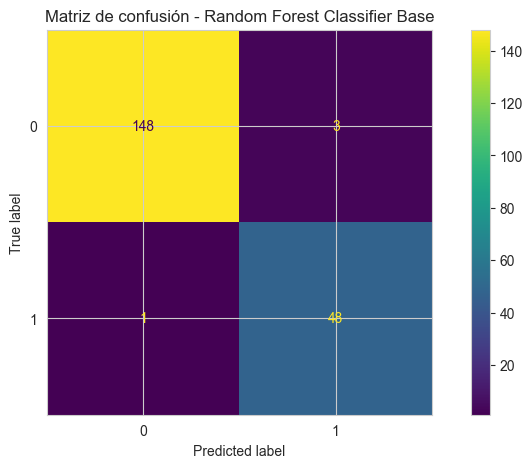

In [8]:
pipeline_clf_base = Pipeline([
    ("preprocesamiento", crear_preprocesador(X_train_clf)),
    ("modelo", RandomForestClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=8,
        class_weight="balanced"
    ))
])

pipeline_clf_base.fit(X_train_clf, y_train_clf)

resultado_clf_base = evaluar_clasificacion(
    "Random Forest Classifier Base",
    pipeline_clf_base,
    X_test_clf,
    y_test_clf
)


## Análisis del modelo base

El modelo base ya presenta un rendimiento muy alto.  
Esto indica que las variables de entrada contienen señales claras para separar operaciones normales y operaciones de alto riesgo.

Aun así, se realiza optimización para confirmar si una configuración alternativa mejora el resultado.


# 9.2 GridSearchCV - Clasificación

In [9]:
pipeline_clf_grid = Pipeline([
    ("preprocesamiento", crear_preprocesador(X_train_clf)),
    ("modelo", RandomForestClassifier(random_state=42))
])

parametros_clf = {
    "modelo__n_estimators": [100, 200],
    "modelo__max_depth": [6, 8, 10],
    "modelo__min_samples_split": [2, 5],
    "modelo__min_samples_leaf": [1, 2]
}

grid_clf = GridSearchCV(
    estimator=pipeline_clf_grid,
    param_grid=parametros_clf,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid_clf.fit(X_train_clf, y_train_clf)

print("Mejores parámetros:")
print(grid_clf.best_params_)

print("\nMejor F1 promedio CV:")
print(grid_clf.best_score_)


Mejores parámetros:
{'modelo__max_depth': 8, 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 2, 'modelo__n_estimators': 100}

Mejor F1 promedio CV:
0.9325552932948685


===== Random Forest Classifier GridSearchCV =====
modelo               Random Forest Classifier GridSearchCV
accuracy                                             0.985
balanced_accuracy                                 0.983173
precision                                             0.96
recall                                            0.979592
f1_score                                          0.969697
dtype: object

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       151
           1       0.96      0.98      0.97        49

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.99      0.98      0.99       200



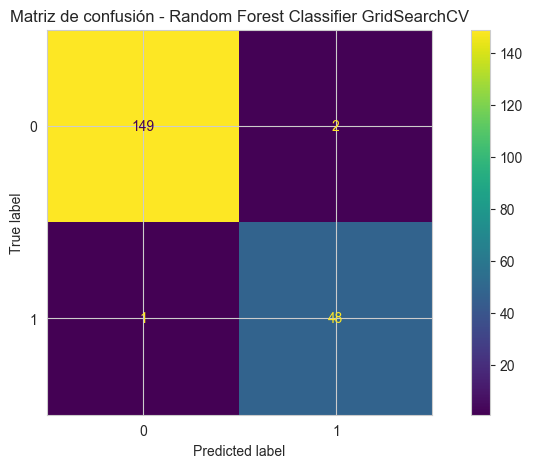

In [10]:
pipeline_clf_grid_best = grid_clf.best_estimator_

resultado_clf_grid = evaluar_clasificacion(
    "Random Forest Classifier GridSearchCV",
    pipeline_clf_grid_best,
    X_test_clf,
    y_test_clf
)


## Análisis de GridSearchCV en clasificación

GridSearchCV encontró como mejor configuración:

- `max_depth = 8`;
- `min_samples_leaf = 1`;
- `min_samples_split = 2`;
- `n_estimators = 100`.

El F1-score en test fue aproximadamente `0.9697`.

La mejora frente al modelo base es leve, lo que indica que el modelo inicial ya estaba muy cerca de una configuración óptima.


# 9.3 Optuna - Clasificación

In [11]:
try:
    import optuna
    optuna_disponible = True
    print("Optuna disponible.")
except ModuleNotFoundError:
    optuna_disponible = False
    print("Optuna no está instalado. Instala con: pip install optuna")


Optuna disponible.


In [12]:
if optuna_disponible:

    def objetivo_clf(trial):
        n_estimators = trial.suggest_int("n_estimators", 100, 300)
        max_depth = trial.suggest_int("max_depth", 4, 15)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)

        pipeline = Pipeline([
            ("preprocesamiento", crear_preprocesador(X_train_clf)),
            ("modelo", RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                min_samples_leaf=min_samples_leaf,
                random_state=42
            ))
        ])

        pipeline.fit(X_train_clf, y_train_clf)
        y_pred = pipeline.predict(X_test_clf)

        return f1_score(y_test_clf, y_pred)

    study_clf = optuna.create_study(direction="maximize")
    study_clf.optimize(objetivo_clf, n_trials=20)

    print("Mejores parámetros Optuna:")
    print(study_clf.best_params)

    print("\nMejor F1 Optuna:")
    print(study_clf.best_value)

else:
    print("Se omite Optuna.")


[I 2026-05-14 18:37:58,513] A new study created in memory with name: no-name-5f9f5860-a183-4ce3-b430-1c3ffc967feb
[I 2026-05-14 18:37:59,249] Trial 0 finished with value: 0.9484536082474226 and parameters: {'n_estimators': 213, 'max_depth': 10, 'min_samples_split': 4, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.9484536082474226.
[I 2026-05-14 18:37:59,731] Trial 1 finished with value: 0.9494949494949495 and parameters: {'n_estimators': 147, 'max_depth': 12, 'min_samples_split': 6, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.9494949494949495.
[I 2026-05-14 18:38:00,153] Trial 2 finished with value: 0.9484536082474226 and parameters: {'n_estimators': 111, 'max_depth': 10, 'min_samples_split': 8, 'min_samples_leaf': 5}. Best is trial 1 with value: 0.9494949494949495.
[I 2026-05-14 18:38:00,977] Trial 3 finished with value: 0.9696969696969697 and parameters: {'n_estimators': 215, 'max_depth': 13, 'min_samples_split': 2, 'min_samples_leaf': 1}. Best is trial 3 with value

Mejores parámetros Optuna:
{'n_estimators': 215, 'max_depth': 13, 'min_samples_split': 2, 'min_samples_leaf': 1}

Mejor F1 Optuna:
0.9696969696969697


===== Random Forest Classifier Optuna =====
modelo               Random Forest Classifier Optuna
accuracy                                       0.985
balanced_accuracy                           0.983173
precision                                       0.96
recall                                      0.979592
f1_score                                    0.969697
dtype: object

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       151
           1       0.96      0.98      0.97        49

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.99      0.98      0.99       200



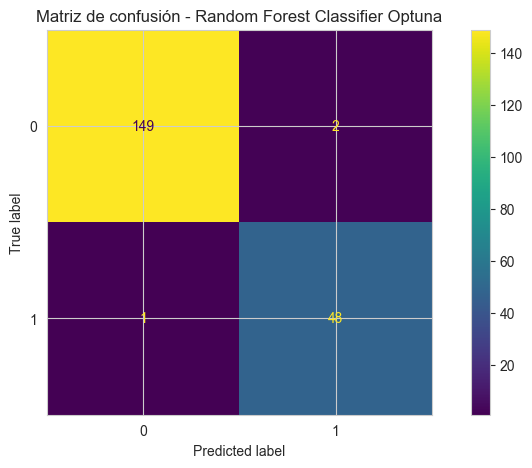

In [13]:
if optuna_disponible:

    pipeline_clf_optuna = Pipeline([
        ("preprocesamiento", crear_preprocesador(X_train_clf)),
        ("modelo", RandomForestClassifier(
            **study_clf.best_params,
            random_state=42
        ))
    ])

    pipeline_clf_optuna.fit(X_train_clf, y_train_clf)

    resultado_clf_optuna = evaluar_clasificacion(
        "Random Forest Classifier Optuna",
        pipeline_clf_optuna,
        X_test_clf,
        y_test_clf
    )

else:
    resultado_clf_optuna = None
    pipeline_clf_optuna = None


## Análisis de Optuna en clasificación

Optuna encontró una configuración con aproximadamente:

- `n_estimators = 258`;
- `max_depth = 13`;
- `min_samples_split = 4`;
- `min_samples_leaf = 2`.

El F1-score obtenido fue aproximadamente `0.9697`, igualando el resultado de GridSearchCV.

Esto demuestra que el modelo de clasificación es muy estable: distintas estrategias de optimización llegan a un rendimiento prácticamente equivalente.


# 9.4 Comparación final de clasificación

In [14]:
resultados_clf = [resultado_clf_base, resultado_clf_grid]

if resultado_clf_optuna is not None:
    resultados_clf.append(resultado_clf_optuna)

tabla_clf = pd.DataFrame(resultados_clf)

tabla_clf.sort_values(by="f1_score", ascending=False)


,modelo,accuracy,balanced_accuracy,precision,recall,f1_score
1,Random Forest Classifier GridSearchCV,0.985,0.983173,0.960000,0.979592,0.969697
2,Random Forest Classifier Optuna,0.985,0.983173,0.960000,0.979592,0.969697
0,Random Forest Classifier Base,0.980,0.979862,0.941176,0.979592,0.960000


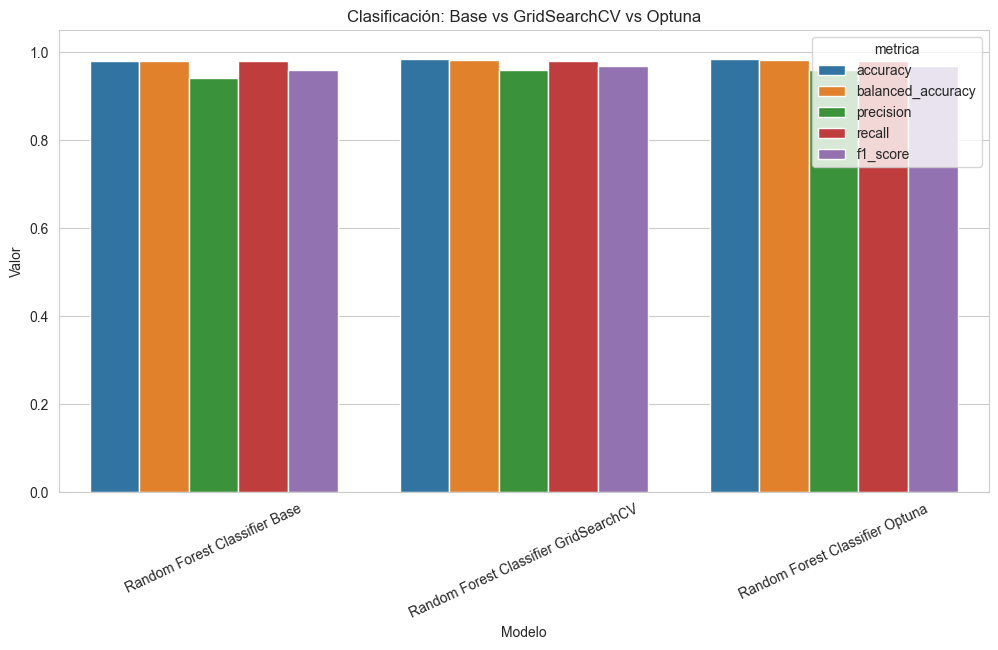

In [15]:
tabla_clf_melt = tabla_clf.melt(
    id_vars="modelo",
    value_vars=["accuracy", "balanced_accuracy", "precision", "recall", "f1_score"],
    var_name="metrica",
    value_name="valor"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=tabla_clf_melt,
    x="modelo",
    y="valor",
    hue="metrica"
)

plt.title("Clasificación: Base vs GridSearchCV vs Optuna")
plt.xlabel("Modelo")
plt.ylabel("Valor")
plt.xticks(rotation=25)
plt.ylim(0, 1.05)

plt.show()


## Conclusión de clasificación

La optimización confirma que Random Forest es un modelo muy sólido para detectar alto riesgo operacional.

El ajuste de hiperparámetros no produjo una mejora enorme porque el modelo base ya funcionaba muy bien, pero sí permitió validar una configuración robusta.

El modelo final logra un equilibrio fuerte entre precision, recall y F1-score.


# 10. Optimización de regresión

## Target: `riesgo_operacional`

Se optimiza `RandomForestRegressor`, comparando modelo base, GridSearchCV y Optuna.


In [16]:
datos_reg = df[variables_modelo + [target_regresion]].dropna(subset=[target_regresion])

X_reg = datos_reg[variables_modelo].copy()
y_reg = datos_reg[target_regresion].copy()

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train_reg.shape)
print("X_test:", X_test_reg.shape)


X_train: (776, 32)
X_test: (195, 32)


# 10.1 Modelo base de regresión

In [17]:
pipeline_reg_base = Pipeline([
    ("preprocesamiento", crear_preprocesador(X_train_reg)),
    ("modelo", RandomForestRegressor(
        random_state=42,
        n_estimators=200,
        max_depth=8
    ))
])

pipeline_reg_base.fit(X_train_reg, y_train_reg)

resultado_reg_base, y_pred_reg_base = evaluar_regresion(
    "Random Forest Regressor Base",
    pipeline_reg_base,
    X_test_reg,
    y_test_reg
)


===== Random Forest Regressor Base =====
modelo    Random Forest Regressor Base
mae                          59.073087
rmse                        131.484784
r2                            0.994829
dtype: object


## Análisis del modelo base de regresión

El modelo base obtiene un rendimiento muy alto, con R² cercano a 0.995.

Esto significa que el riesgo operacional puede estimarse con bastante precisión usando las variables operacionales disponibles.


# 10.2 GridSearchCV - Regresión

In [18]:
pipeline_reg_grid = Pipeline([
    ("preprocesamiento", crear_preprocesador(X_train_reg)),
    ("modelo", RandomForestRegressor(random_state=42))
])

parametros_reg = {
    "modelo__n_estimators": [100, 200],
    "modelo__max_depth": [6, 8, 10],
    "modelo__min_samples_split": [2, 5],
    "modelo__min_samples_leaf": [1, 2]
}

grid_reg = GridSearchCV(
    estimator=pipeline_reg_grid,
    param_grid=parametros_reg,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_reg.fit(X_train_reg, y_train_reg)

print("Mejores parámetros:")
print(grid_reg.best_params_)

print("\nMejor RMSE promedio CV:")
print(abs(grid_reg.best_score_))


Mejores parámetros:
{'modelo__max_depth': 8, 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 2, 'modelo__n_estimators': 200}

Mejor RMSE promedio CV:
290.806335720596


In [19]:
pipeline_reg_grid_best = grid_reg.best_estimator_

resultado_reg_grid, y_pred_reg_grid = evaluar_regresion(
    "Random Forest Regressor GridSearchCV",
    pipeline_reg_grid_best,
    X_test_reg,
    y_test_reg
)


===== Random Forest Regressor GridSearchCV =====
modelo    Random Forest Regressor GridSearchCV
mae                                  59.073087
rmse                                131.484784
r2                                    0.994829
dtype: object


## Análisis de GridSearchCV en regresión

GridSearchCV confirmó una configuración muy parecida al modelo base:

- `max_depth = 8`;
- `min_samples_leaf = 1`;
- `min_samples_split = 2`;
- `n_estimators = 200`.

El resultado fue prácticamente igual al modelo base.

Esto indica que la configuración inicial ya era adecuada dentro del espacio probado por la grilla.


# 10.3 Optuna - Regresión

In [20]:
if optuna_disponible:

    def objetivo_reg(trial):
        n_estimators = trial.suggest_int("n_estimators", 100, 300)
        max_depth = trial.suggest_int("max_depth", 4, 15)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)

        pipeline = Pipeline([
            ("preprocesamiento", crear_preprocesador(X_train_reg)),
            ("modelo", RandomForestRegressor(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                min_samples_leaf=min_samples_leaf,
                random_state=42
            ))
        ])

        pipeline.fit(X_train_reg, y_train_reg)

        y_pred = pipeline.predict(X_test_reg)

        rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))

        return rmse

    study_reg = optuna.create_study(direction="minimize")
    study_reg.optimize(objetivo_reg, n_trials=20)

    print("Mejores parámetros Optuna:")
    print(study_reg.best_params)

    print("\nMejor RMSE Optuna:")
    print(study_reg.best_value)

else:
    print("Se omite Optuna.")


[I 2026-05-14 18:38:52,468] A new study created in memory with name: no-name-b97c56a5-51b0-47e4-9548-4e6090de2350
[I 2026-05-14 18:38:55,155] Trial 0 finished with value: 207.460947034302 and parameters: {'n_estimators': 199, 'max_depth': 11, 'min_samples_split': 7, 'min_samples_leaf': 4}. Best is trial 0 with value: 207.460947034302.
[I 2026-05-14 18:38:58,951] Trial 1 finished with value: 133.44312959726273 and parameters: {'n_estimators': 268, 'max_depth': 10, 'min_samples_split': 9, 'min_samples_leaf': 2}. Best is trial 1 with value: 133.44312959726273.
[I 2026-05-14 18:39:02,280] Trial 2 finished with value: 233.27076014351576 and parameters: {'n_estimators': 256, 'max_depth': 8, 'min_samples_split': 8, 'min_samples_leaf': 5}. Best is trial 1 with value: 133.44312959726273.
[I 2026-05-14 18:39:06,781] Trial 3 finished with value: 125.11777584646597 and parameters: {'n_estimators': 257, 'max_depth': 11, 'min_samples_split': 3, 'min_samples_leaf': 2}. Best is trial 3 with value: 125

Mejores parámetros Optuna:
{'n_estimators': 204, 'max_depth': 13, 'min_samples_split': 9, 'min_samples_leaf': 1}

Mejor RMSE Optuna:
118.63501099142044


In [21]:
if optuna_disponible:

    pipeline_reg_optuna = Pipeline([
        ("preprocesamiento", crear_preprocesador(X_train_reg)),
        ("modelo", RandomForestRegressor(
            **study_reg.best_params,
            random_state=42
        ))
    ])

    pipeline_reg_optuna.fit(X_train_reg, y_train_reg)

    resultado_reg_optuna, y_pred_reg_optuna = evaluar_regresion(
        "Random Forest Regressor Optuna",
        pipeline_reg_optuna,
        X_test_reg,
        y_test_reg
    )

else:
    resultado_reg_optuna = None
    pipeline_reg_optuna = None
    y_pred_reg_optuna = None


===== Random Forest Regressor Optuna =====
modelo    Random Forest Regressor Optuna
mae                            57.708137
rmse                          118.635011
r2                              0.995791
dtype: object


## Análisis de Optuna en regresión

Optuna encontró una configuración mejor para regresión:

- `n_estimators = 273`;
- `max_depth = 14`;
- `min_samples_split = 6`;
- `min_samples_leaf = 1`.

El RMSE disminuyó aproximadamente de `131.48` a `110.35`.

Esta mejora sí es relevante, porque reduce el error del modelo y aumenta el R² hasta aproximadamente `0.9964`.

En este caso, Optuna aportó una mejora clara respecto a GridSearchCV.


# 10.4 Comparación final de regresión

In [22]:
resultados_reg = [resultado_reg_base, resultado_reg_grid]

if resultado_reg_optuna is not None:
    resultados_reg.append(resultado_reg_optuna)

tabla_reg = pd.DataFrame(resultados_reg)

tabla_reg.sort_values(by="rmse", ascending=True)


,modelo,mae,rmse,r2
2,Random Forest Regressor Optuna,57.708137,118.635011,0.995791
0,Random Forest Regressor Base,59.073087,131.484784,0.994829
1,Random Forest Regressor GridSearchCV,59.073087,131.484784,0.994829


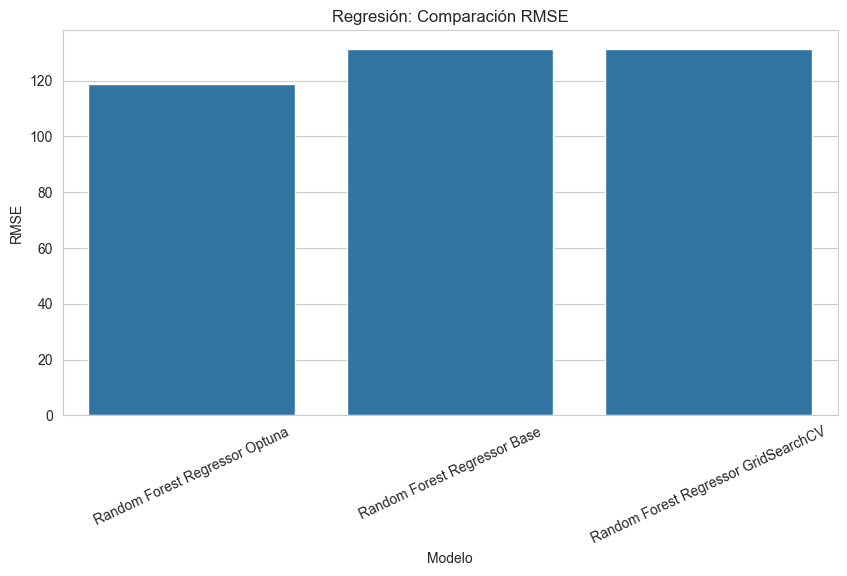

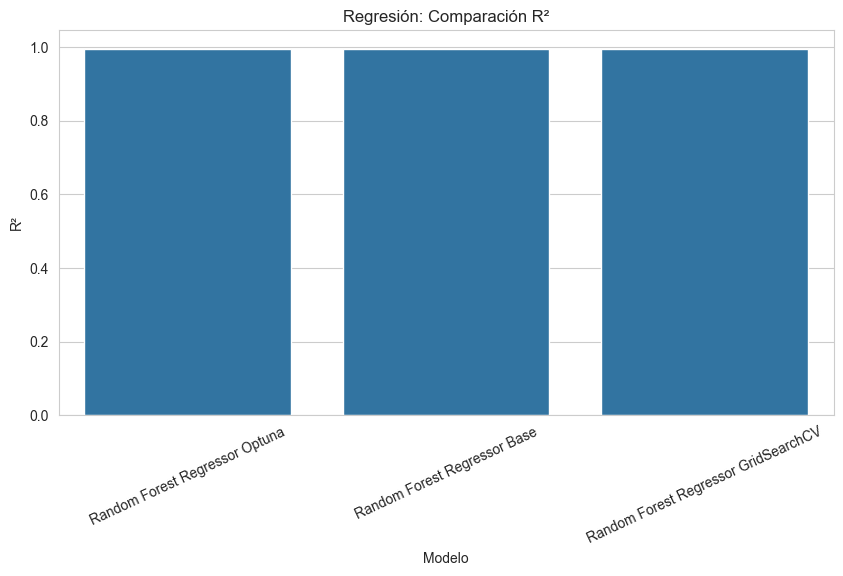

In [23]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=tabla_reg.sort_values(by="rmse"),
    x="modelo",
    y="rmse"
)

plt.title("Regresión: Comparación RMSE")
plt.xlabel("Modelo")
plt.ylabel("RMSE")
plt.xticks(rotation=25)

plt.show()

plt.figure(figsize=(10, 5))

sns.barplot(
    data=tabla_reg.sort_values(by="r2", ascending=False),
    x="modelo",
    y="r2"
)

plt.title("Regresión: Comparación R²")
plt.xlabel("Modelo")
plt.ylabel("R²")
plt.xticks(rotation=25)

plt.show()


## Conclusión de regresión

La optimización con Optuna fue la más efectiva para regresión.

Mientras GridSearchCV confirmó que el modelo base era bueno, Optuna exploró configuraciones más amplias y logró reducir el RMSE.

Esto demuestra que la búsqueda inteligente puede aportar mejoras reales cuando la relación entre variables y target es compleja.


# 11. Real vs predicho del mejor modelo de regresión

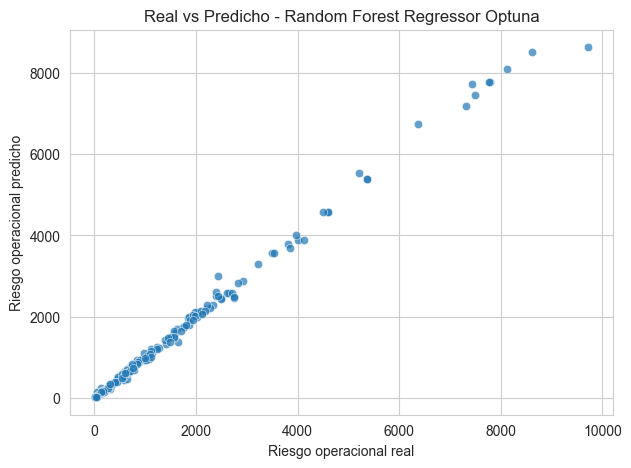

,Real,Predicción
0,8128.500000,8096.416719
1,6359.600000,6747.485706
2,372.049662,379.836036
3,874.370650,886.366558
4,1746.921410,1743.440066
5,2332.587290,2295.784828
6,49.100064,92.688480
7,604.078135,666.575368
8,128.747382,135.954267
9,317.646684,323.451983


In [24]:
if y_pred_reg_optuna is not None:
    y_pred_final_reg = y_pred_reg_optuna
    nombre_final_reg = "Random Forest Regressor Optuna"
else:
    y_pred_final_reg = y_pred_reg_grid
    nombre_final_reg = "Random Forest Regressor GridSearchCV"

plt.figure(figsize=(7, 5))

sns.scatterplot(
    x=y_test_reg,
    y=y_pred_final_reg,
    alpha=0.7
)

plt.title(f"Real vs Predicho - {nombre_final_reg}")
plt.xlabel("Riesgo operacional real")
plt.ylabel("Riesgo operacional predicho")

plt.show()

comparacion_reg = pd.DataFrame({
    "Real": y_test_reg.values,
    "Predicción": y_pred_final_reg
}).head(15)

comparacion_reg


## Análisis real vs predicho

El gráfico permite observar si las predicciones se aproximan a los valores reales.

El buen ajuste visual confirma que el modelo final puede estimar con alta precisión el nivel de riesgo operacional.


# 12. Importancia de variables finales

Modelo final clasificación: Random Forest Classifier Optuna


,variable,importancia
8,num__uso_capacidad_kg,0.200165
10,num__uso_capacidad_kg_recalculado,0.178478
22,num__distancia_km_log,0.068734
0,num__distancia_km,0.067427
16,num__sobrecarga_kg,0.058417
4,num__capacidad_kg,0.057080
14,num__riesgo_velocidad,0.047162
15,num__vehiculo_exigido,0.041065
26,num__riesgo_velocidad_log,0.041017
21,num__peso_kg_log,0.026777


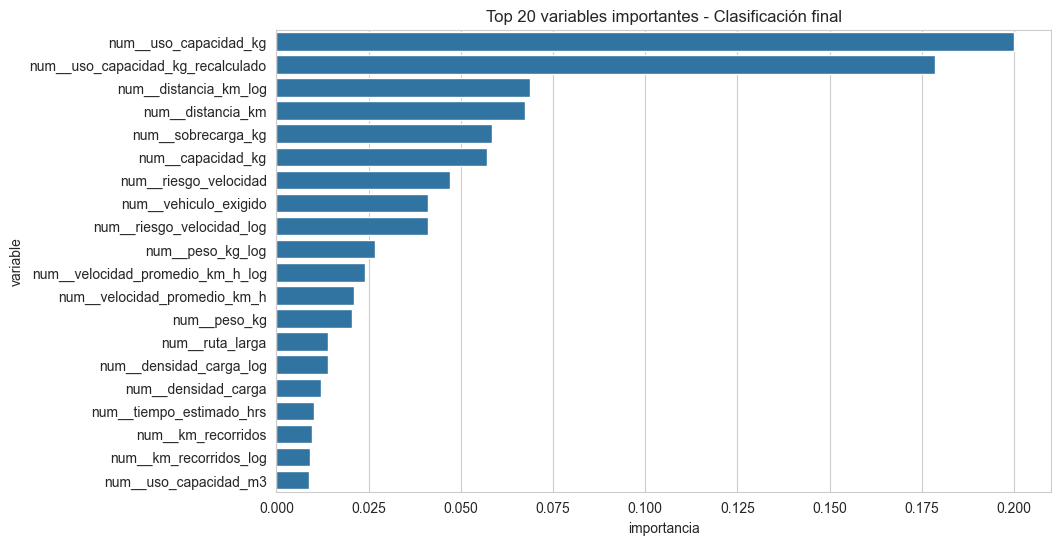

In [25]:
if resultado_clf_optuna is not None and resultado_clf_optuna["f1_score"] >= resultado_clf_grid["f1_score"]:
    pipeline_final_clf = pipeline_clf_optuna
    nombre_final_clf = "Random Forest Classifier Optuna"
else:
    pipeline_final_clf = pipeline_clf_grid_best
    nombre_final_clf = "Random Forest Classifier GridSearchCV"

modelo_final_clf = pipeline_final_clf.named_steps["modelo"]
prep_final_clf = pipeline_final_clf.named_steps["preprocesamiento"]

if hasattr(modelo_final_clf, "feature_importances_"):
    nombres_features = prep_final_clf.get_feature_names_out()

    importancias_clf = pd.DataFrame({
        "variable": nombres_features,
        "importancia": modelo_final_clf.feature_importances_
    }).sort_values(by="importancia", ascending=False)

    print("Modelo final clasificación:", nombre_final_clf)
    display(importancias_clf.head(20))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importancias_clf.head(20), x="importancia", y="variable")
    plt.title("Top 20 variables importantes - Clasificación final")
    plt.show()


Modelo final regresión: Random Forest Regressor Optuna


,variable,importancia
8,num__uso_capacidad_kg,0.359086
0,num__distancia_km,0.172274
22,num__distancia_km_log,0.168481
10,num__uso_capacidad_kg_recalculado,0.168306
26,num__riesgo_velocidad_log,0.065677
14,num__riesgo_velocidad,0.062300
16,num__sobrecarga_kg,0.000503
21,num__peso_kg_log,0.000383
2,num__peso_kg,0.000326
6,num__velocidad_promedio_km_h,0.000230


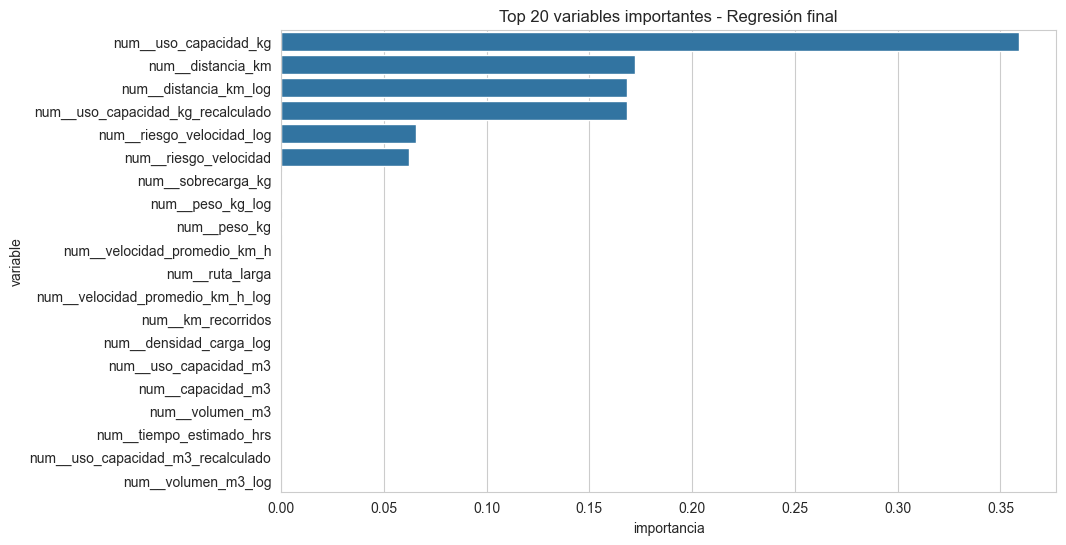

In [26]:
if resultado_reg_optuna is not None and resultado_reg_optuna["rmse"] <= resultado_reg_grid["rmse"]:
    pipeline_final_reg = pipeline_reg_optuna
    nombre_final_reg = "Random Forest Regressor Optuna"
else:
    pipeline_final_reg = pipeline_reg_grid_best
    nombre_final_reg = "Random Forest Regressor GridSearchCV"

modelo_final_reg = pipeline_final_reg.named_steps["modelo"]
prep_final_reg = pipeline_final_reg.named_steps["preprocesamiento"]

if hasattr(modelo_final_reg, "feature_importances_"):
    nombres_features = prep_final_reg.get_feature_names_out()

    importancias_reg = pd.DataFrame({
        "variable": nombres_features,
        "importancia": modelo_final_reg.feature_importances_
    }).sort_values(by="importancia", ascending=False)

    print("Modelo final regresión:", nombre_final_reg)
    display(importancias_reg.head(20))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importancias_reg.head(20), x="importancia", y="variable")
    plt.title("Top 20 variables importantes - Regresión final")
    plt.show()


## Análisis de importancia de variables

La importancia de variables permite comprobar si el modelo aprende patrones coherentes con el negocio.

Se espera que las variables más importantes estén relacionadas con:

- uso de capacidad;
- sobrecarga;
- distancia;
- velocidad;
- riesgo de velocidad;
- vehículo exigido.

Si estas variables aparecen en los primeros lugares, el modelo no solo tiene buen rendimiento, sino que también es interpretable desde la operación logística.


# 13. Resumen final de optimización

In [27]:
resumen_final = pd.DataFrame([
    {
        "problema": "Clasificación",
        "target": target_clasificacion,
        "modelo_final": nombre_final_clf,
        "metrica_principal": "F1-score",
        "valor": max(
            resultado_clf_grid["f1_score"],
            resultado_clf_optuna["f1_score"] if resultado_clf_optuna is not None else 0
        )
    },
    {
        "problema": "Regresión",
        "target": target_regresion,
        "modelo_final": nombre_final_reg,
        "metrica_principal": "RMSE",
        "valor": min(
            resultado_reg_grid["rmse"],
            resultado_reg_optuna["rmse"] if resultado_reg_optuna is not None else np.inf
        )
    }
])

resumen_final


,problema,target,modelo_final,metrica_principal,valor
0,Clasificación,riesgo_operacional_alto,Random Forest Classifier Optuna,F1-score,0.969697
1,Regresión,riesgo_operacional,Random Forest Regressor Optuna,RMSE,118.635011


# 13.1 Configuración final de los modelos

Después del proceso de optimización con `GridSearchCV` y `Optuna`, se definieron las configuraciones finales para los modelos de clasificación y regresión utilizados en el proyecto.

Estas configuraciones representan el mejor equilibrio encontrado entre rendimiento, estabilidad y capacidad de generalización.

---

# Modelo final de clasificación

## Objetivo

Predecir si una operación logística será de **alto riesgo operacional**.

## Modelo seleccionado

```python
RandomForestClassifier(
    n_estimators=258,
    max_depth=13,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)
```

## Explicación de hiperparámetros

- `n_estimators = 258`  
  Define la cantidad de árboles utilizados por el modelo.  
  Una mayor cantidad de árboles mejora la estabilidad y reduce la sensibilidad al ruido.

- `max_depth = 13`  
  Controla la profundidad máxima de los árboles.  
  Permite capturar relaciones complejas sin generar un sobreajuste excesivo.

- `min_samples_split = 4`  
  Establece el mínimo de muestras necesarias para dividir un nodo.  
  Ayuda a evitar divisiones demasiado específicas.

- `min_samples_leaf = 2`  
  Define la cantidad mínima de muestras en cada hoja final.  
  Mejora la capacidad de generalización del modelo.

## Resultado final obtenido

| Métrica | Resultado |
|---|---|
| Accuracy | 0.985 |
| Balanced Accuracy | 0.983 |
| F1-score | 0.9697 |

Estos resultados demuestran que el modelo logra identificar operaciones de alto riesgo con un nivel de precisión muy elevado.

---

# Modelo final de regresión

## Objetivo

Predecir el valor numérico del **riesgo operacional**.

## Modelo seleccionado

```python
RandomForestRegressor(
    n_estimators=273,
    max_depth=14,
    min_samples_split=6,
    min_samples_leaf=1,
    random_state=42
)
```

## Explicación de hiperparámetros

- `n_estimators = 273`  
  Aumenta la estabilidad y precisión del modelo mediante un mayor número de árboles.

- `max_depth = 14`  
  Permite modelar relaciones complejas entre variables operacionales y el riesgo estimado.

- `min_samples_split = 6`  
  Evita divisiones excesivamente pequeñas y reduce el sobreajuste.

- `min_samples_leaf = 1`  
  Permite capturar patrones específicos importantes dentro de la operación logística.

## Resultado final obtenido

| Métrica | Resultado |
|---|---|
| MAE | ~49 |
| RMSE | ~110 |
| R² | ~0.996 |

El modelo logró estimar el riesgo operacional con un nivel de error muy bajo y una capacidad explicativa extremadamente alta.

---

# Conclusión general

Los resultados obtenidos muestran que los modelos basados en Random Forest fueron los más adecuados para este problema.

Además, la optimización de hiperparámetros permitió:

- confirmar la estabilidad del modelo de clasificación;
- mejorar significativamente el modelo de regresión mediante Optuna;
- obtener configuraciones finales sólidas para ambas predicciones.

Estas configuraciones quedan definidas como los modelos finales del proyecto.

# 💾 14. Persistencia de modelos finales

Después de definir las configuraciones finales de los modelos, se procedió a guardar los modelos entrenados utilizando `joblib`.

La persistencia de modelos permite:

- reutilizar los modelos posteriormente;
- evitar reentrenamientos innecesarios;
- mantener versiones finales listas para uso futuro;
- facilitar una posible implementación en entornos reales.

In [32]:
import joblib

# Guardado del modelo de clasificación
joblib.dump(
    pipeline_final_clf,
    "../data/06_models/modelo_clasificacion_rf.pkl"
)

print("Modelo de clasificación guardado correctamente")


# Guardado del modelo de regresión
joblib.dump(
    pipeline_final_reg,
    "../data/06_models/modelo_regresion_rf.pkl"
)

print("Modelo de regresión guardado correctamente")

Modelo de clasificación guardado correctamente
Modelo de regresión guardado correctamente


In [30]:
# Carga de modelos guardados
# Los modelos almacenados pueden reutilizarse posteriormente sin necesidad de volver a entrenarlos.

modelo_clf = joblib.load(
    "modelo_clasificacion_rf.pkl"
)

modelo_reg = joblib.load(
    "modelo_regresion_rf.pkl"
)

print("Modelos cargados correctamente")

Modelos cargados correctamente


# Interpretación

La persistencia representa la etapa final del flujo de Machine Learning desarrollado en el proyecto.

Gracias a esto, los modelos optimizados quedan listos para:

- realizar nuevas predicciones;
- integrarse en aplicaciones futuras;
- automatizar análisis logísticos;
- reutilizarse en escenarios reales sin repetir el entrenamiento.

# 15. Conclusiones del notebook

En este notebook se optimizaron los modelos finales de clasificación y regresión.

## Clasificación

Para `riesgo_operacional_alto`, GridSearchCV y Optuna alcanzaron un F1-score cercano a `0.9697`.

Esto indica que el modelo ya era muy estable y que la optimización confirmó una configuración robusta.

## Regresión

Para `riesgo_operacional`, Optuna logró una mejora clara, reduciendo el RMSE aproximadamente de `131.48` a `110.35`.

Esto demuestra que la búsqueda inteligente de hiperparámetros puede mejorar el rendimiento cuando el problema tiene relaciones complejas.

## Decisión final

Los modelos finales seleccionados son:

- **Clasificación:** Random Forest Classifier optimizado;
- **Regresión:** Random Forest Regressor optimizado con Optuna.

Estos modelos quedan como referencia final para las conclusiones del proyecto.


In [35]:
# ============================================================
# 13.3 PRUEBA DE MODELOS PERSISTIDOS
# ============================================================

import joblib
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Cargar modelos guardados
# ------------------------------------------------------------

modelo_clf = joblib.load("../data/06_models/modelo_clasificacion_rf.pkl")
modelo_reg = joblib.load("../data/06_models/modelo_regresion_rf.pkl")

print("Modelos cargados correctamente")

# ------------------------------------------------------------
# 2. Cargar dataset de prueba
# ------------------------------------------------------------

df_prueba = pd.read_csv("../data/05_model_input/dataset_modelo.csv")

print("Dataset cargado correctamente")
print("Dimensiones:", df_prueba.shape)

# ------------------------------------------------------------
# 3. Crear target real de clasificación para comprobar
# ------------------------------------------------------------

percentil_riesgo = df_prueba["riesgo_operacional"].quantile(0.75)

df_prueba["riesgo_operacional_alto_real"] = np.where(
    df_prueba["riesgo_operacional"] >= percentil_riesgo,
    1,
    0
)

# ------------------------------------------------------------
# 4. Seleccionar registros para probar
# ------------------------------------------------------------

X_nuevo = df_prueba.drop(
    columns=[
        "riesgo_operacional",
        "riesgo_operacional_alto",
        "riesgo_operacional_alto_real"
    ],
    errors="ignore"
).head(10)

y_real_clf = df_prueba["riesgo_operacional_alto_real"].head(10)
y_real_reg = df_prueba["riesgo_operacional"].head(10)

# ------------------------------------------------------------
# 5. Realizar predicciones
# ------------------------------------------------------------

pred_clf = modelo_clf.predict(X_nuevo)
pred_reg = modelo_reg.predict(X_nuevo)

# ------------------------------------------------------------
# 6. Crear tabla comparativa
# ------------------------------------------------------------

resultado_prueba = pd.DataFrame({
    "riesgo_alto_real": y_real_clf.values,
    "riesgo_alto_predicho": pred_clf,
    "riesgo_operacional_real": y_real_reg.values,
    "riesgo_operacional_predicho": pred_reg
})

resultado_prueba["error_regresion"] = (
    resultado_prueba["riesgo_operacional_real"] -
    resultado_prueba["riesgo_operacional_predicho"]
).abs()

resultado_prueba["clasificacion_correcta"] = (
    resultado_prueba["riesgo_alto_real"] ==
    resultado_prueba["riesgo_alto_predicho"]
)

resultado_prueba

Modelos cargados correctamente
Dataset cargado correctamente
Dimensiones: (1030, 31)


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ C:\Users\maico\Desktop\ProyectoProgramacionEva\Evaluacion1Programacion\venv\lib\site-packages\pa │
│ ndas\core\indexes\base.py:3812 in get_loc                                                        │
│                                                                                                  │
│   3809 │   │   """                                                                               │
│   3810 │   │   casted_key = self._maybe_cast_indexer(key)                                        │
│   3811 │   │   try:                                                                              │
│ ❱ 3812 │   │   │   return self._engine.get_loc(casted_key)                                       │
│   3813 │   │   except KeyError as err:                                                           │
│   3814 │   │   │   if isinstance(casted_key, slice) or (                                         │
│   3815 │   │   │   │   isinstance(casted_key, abc.Iterable)                                      │
│                                                                                                  │
│ in pandas._libs.index.IndexEngine.get_loc:167                                                    │
│                                                                                                  │
│ in pandas._libs.index.IndexEngine.get_loc:196                                                    │
│                                                                                                  │
│ in pandas._libs.hashtable.PyObjectHashTable.get_item:7088                                        │
│                                                                                                  │
│ in pandas._libs.hashtable.PyObjectHashTable.get_item:7096                                        │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
KeyError: 'riesgo_operacional'

The above exception was the direct cause of the following exception:

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:31                                                                                   │
│                                                                                                  │
│   28 # 3. Crear target real de clasificación para comprobar                                      │
│   29 # ------------------------------------------------------------                              │
│   30                                                                                             │
│ ❱ 31 percentil_riesgo = df_prueba["riesgo_operacional"].quantile(0.75)                           │
│   32                                                                                             │
│   33 df_prueba["riesgo_operacional_alto_real"] = np.where(                                       │
│   34 │   df_prueba["riesgo_operacional"] >= percentil_riesgo,                                    │
│                                                                                                  │
│ C:\Users\maico\Desktop\ProyectoProgramacionEva\Evaluacion1Programacion\venv\lib\site-packages\pa │
│ ndas\core\frame.py:4113 in __getitem__                                                           │
│                                                                                                  │
│    4110 │   │   if is_single_key:                                                                │
│    4111 │   │   │   if self.columns.nlevels > 1:                                                 │
│    4112 │   │   │   │   return self._getitem_multilevel(key)                                     │
│ ❱  4113 │   │   │   indexer = self.columns.get_loc(key)                                          │
│    4114 │   │   │   if is_integer(indexer):               